##  Exploring Overfitting in Convolutional Neural Networks (CNNs)

### 1. Introduction
In this exercise you will investigate the problem of overfitting in convolutional neural networks. Overfitting occurs when a model learns the training data too well—including noise and outliers—and fails to generalize to new, unseen data (validation or test set). The goal is to understand why overfitting happens in CNNs and how to mitigate it.

---

### 2. Exercise Title
**Impact of Overfitting and Mitigation Techniques in Convolutional Neural Networks**

---

### 3. Objectives
- Understand the concept of overfitting in CNN models  
- Learn metrics and visual cues for detecting overfitting  
- Implement and compare methods to reduce overfitting such as Regularization, Dropout, and Data Augmentation  

---

### 4. General Instructions
1. Build a simple CNN (e.g., LeNet or another small custom architecture) on Fashion MNIST.  
2. Plot **Loss** and **Accuracy** curves for both training and validation sets.  
3. Identify signs of overfitting (e.g., validation accuracy plateaus or drops while training accuracy continues to rise).  
4. Implement at least two of the following techniques and compare their effects:
   - BatchNorm  
   - Dropout  
   - Data Augmentation  
   - Early Stopping  
5. Analyze your results and write a brief report explaining how each method helped reduce overfitting.

---

### 5. Fill in the Blanks
1. **Overfitting** occurs when .  
2. In the Loss plot, a sign of overfitting is when .  
3. The **Dropout** technique prevents overfitting by .  
4. **Data Augmentation** includes operations .  
5. The main advantage of **Early Stopping** is that it .

---

### 6. Questions
1. Why are convolutional neural networks more or less prone to overfitting compared to fully connected networks?  
2. What is the main difference between L1 and L2 regularization, and how does each affect the model’s weights?  
3. If some overfitting remains after applying the above techniques, what other strategies could you try?  
4. How can you adjust architectural hyperparameters (e.g., number of layers or number of filters) to help prevent overfitting?  
5. Describe a real-world application of CNNs where overfitting was a concern and explain how it was addressed.

---

### 7. Evaluation Criteria
- Correct implementation of the CNN and plotting of curves  
- Completeness and accuracy of the filled-in blanks  
- Depth and clarity of your analyses and answers  
- Clear, well-documented Markdown formatting

---

#### Good luck!


# Personal Info

Name: 

Student Number: 

Mahshid Radaie 
401101749

**note that i just implement erly stopping , droupout and data augmentation not batch normalization**

# Introduction

* Importing libraries

* Helper functions

* Plotting functions

* Set seed and set device

## Libraries

First, let's download the necessary libraries that are used throughout the assignment.

In [1]:
import time
import torch
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm, trange
from PIL import Image
import requests, os
import random
from scipy.signal import correlate2d
import zipfile, gzip, shutil, tarfile

## Helper Functioins

In [3]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║           🚫  DO NOT CHANGE THIS CELL!  🚫            ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #

def download_data(fname, folder, url, tar):
  """
  Data downloading from OSF.

  Args:
    fname : str
      The name of the archive
    folder : str
      The name of the destination folder
    url : str
      The download url
    tar : boolean
      `tar=True` the archive is `fname`.tar.gz, `tar=False` is `fname`.zip

  Returns:
    Nothing.
  """

  if not os.path.exists(folder):
    print(f'\nDownloading {folder} dataset...')
    r = requests.get(url, allow_redirects=True)
    with open(fname, 'wb') as fh:
      fh.write(r.content)
    print(f'\nDownloading {folder} completed.')

    print('\nExtracting the files...\n')
    if not tar:
      with zipfile.ZipFile(fname, 'r') as fz:
        fz.extractall()
    else:
      with tarfile.open(fname) as ft:
        ft.extractall()
    # Remove the archive
    os.remove(fname)

    # Extract all .gz files
    foldername = folder + '/raw/'
    for filename in os.listdir(foldername):
      # Remove the extension
      fname = filename.replace('.gz', '')
      # Gunzip all files
      with gzip.open(foldername + filename, 'rb') as f_in:
        with open(foldername + fname, 'wb') as f_out:
          shutil.copyfileobj(f_in, f_out)
          os.remove(foldername+filename)
  else:
    print(f'{folder} dataset has already been downloaded.\n')


def test(model, device, data_loader):
  """
  Test function

  Args:
    net: nn.module
      Net instance
    device: string
      GPU/CUDA if available, CPU otherwise.
    data_loader: torch.loader
      Test loader

  Returns:
    acc: float
      Test accuracy
  """
  model.eval()
  correct = 0
  total = 0
  for data in data_loader:
    inputs, labels = data
    inputs = inputs.to(device).float()
    labels = labels.to(device).long()

    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  acc = 100 * correct / total
  return f"{acc}%"

## Plotting Functions

In [4]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║           🚫  DO NOT CHANGE THIS CELL!  🚫            ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
def display_image_from_greyscale_array(matrix, title):
  """
  Display image from greyscale array

  Args:
    matrix: np.ndarray
      Image
    title: string
      Title of plot

  Returns:
    Nothing
  """
  _matrix = matrix.astype(np.uint8)
  _img = Image.fromarray(_matrix, 'L')
  plt.figure(figsize=(3, 3))
  plt.imshow(_img, cmap='gray', vmin=0, vmax=255) # Using 220 instead of 255 so the examples show up better
  plt.title(title)
  plt.axis('off')


def make_plots(original, actual_convolution, solution):
  """
  Function to build original image/obtained solution and actual convolution

  Args:
    original: np.ndarray
      Image
    actual_convolution: np.ndarray
      Expected convolution output
    solution: np.ndarray
      Obtained convolution output

  Returns:
    Nothing
  """
  display_image_from_greyscale_array(original, "Original Image")
  display_image_from_greyscale_array(actual_convolution, "Convolution result")
  display_image_from_greyscale_array(solution, "Your solution")


def plot_loss_accuracy(train_loss, train_acc,
                       validation_loss, validation_acc):
  """
  Code to plot loss and accuracy

  Args:
    train_loss: list
      Log of training loss
    validation_loss: list
      Log of validation loss
    train_acc: list
      Log of training accuracy
    validation_acc: list
      Log of validation accuracy

  Returns:
    Nothing
  """
  epochs = len(train_loss)
  fig, (ax1, ax2) = plt.subplots(1, 2)
  ax1.plot(list(range(epochs)), train_loss, label='Training Loss')
  ax1.plot(list(range(epochs)), validation_loss, label='Validation Loss')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.set_title('Epoch vs Loss')
  ax1.legend()

  ax2.plot(list(range(epochs)), train_acc, label='Training Accuracy')
  ax2.plot(list(range(epochs)), validation_acc, label='Validation Accuracy')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Accuracy')
  ax2.set_title('Epoch vs Accuracy')
  ax2.legend()
  fig.set_size_inches(15.5, 5.5)

## Set Random Seed and Set Device

In [5]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║          🚫  DO NOT CHANGE THIS CELL!  🚫             ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
# For DL it's important to set the random seed so that you can have a
# baseline to compare your results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness.
  NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [6]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
# using this function, you can be informed whether the notebook uses GPU or CPU.
def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [7]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
SEED = 1404
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 1404 has been set.
GPU is enabled in this notebook.


# Download Fashion MNIST dataset

* The dataset we are going to use consists of a training set of 60,000 examples and a test set of 10,000 examples.Each example is a 28x28 gray scale image, associated with a label from 10 classes.

* Reducing the dataset to just the two categories (T-shirt/top and Shirt) reduces the training time to about 2 minutes.

In [8]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
# webpage: https://github.com/zalandoresearch/fashion-mnist
fname = 'FashionMNIST.tar.gz'
folder = 'FashionMNIST'
url = "https://osf.io/dfhu5/download"
download_data(fname, folder, url, tar=True)




Extracting the files...



In [9]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
def reduce_classes(data):
  """
  Reducing Fashion-MNIST Data to two-categories:
    T-Shirts and Shirts

  Args:
    data: torch.tensor
      Training Data

  Returns:
    data: torch.tensor
      Data with two classes
  """
  # Only want T-Shirts (0) and Shirts (6) labels
  train_idx = (data.targets == 0) | (data.targets == 6)
  data.targets = data.targets[train_idx]
  data.data = data.data[train_idx]

  # Convert Xs predictions to 1, Os predictions to 0
  data.targets[data.targets == 6] = 1

  return data


def get_fashion_mnist_dataset(binary=False, download=False, seed=0):
  """
  Helper function to get Fashion MNIST data

  Args:
    binary: boolean
      If True, training data has only two classes
    download: boolean
      If True, download training data
    seed: int
      Set seed for reproducibility [default: 0]

  Returns:
    train_data: torch.tensor
      Training data
    test_data: torch.tensor
      Test data
    validation_data: torch.tensor
      Validation data
  """
  transform = transforms.Compose([
                                  transforms.ToTensor(),
                                  transforms.Normalize((0.1307,), (0.3081,))
                                  ])

  train_data = datasets.FashionMNIST(root='.',
                                     download=download,
                                     train=True,
                                     transform=transform)


  test_data = datasets.FashionMNIST(root='.',
                                    download=download,
                                    train=False,
                                    transform=transform)

  if binary:
    train_data = reduce_classes(train_data)
    test_data = reduce_classes(test_data)

  set_seed(seed)
  validation_data, test_data = torch.utils.data.random_split(test_data,
                                                             [int(0.8*len(test_data)),
                                                              int(0.2*len(test_data))])

  return train_data, validation_data, test_data

# Visualize the data

In [10]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
num_classes = 2
train_data, validation_data, test_data = get_fashion_mnist_dataset(binary=True, seed=SEED)

Random seed 1404 has been set.


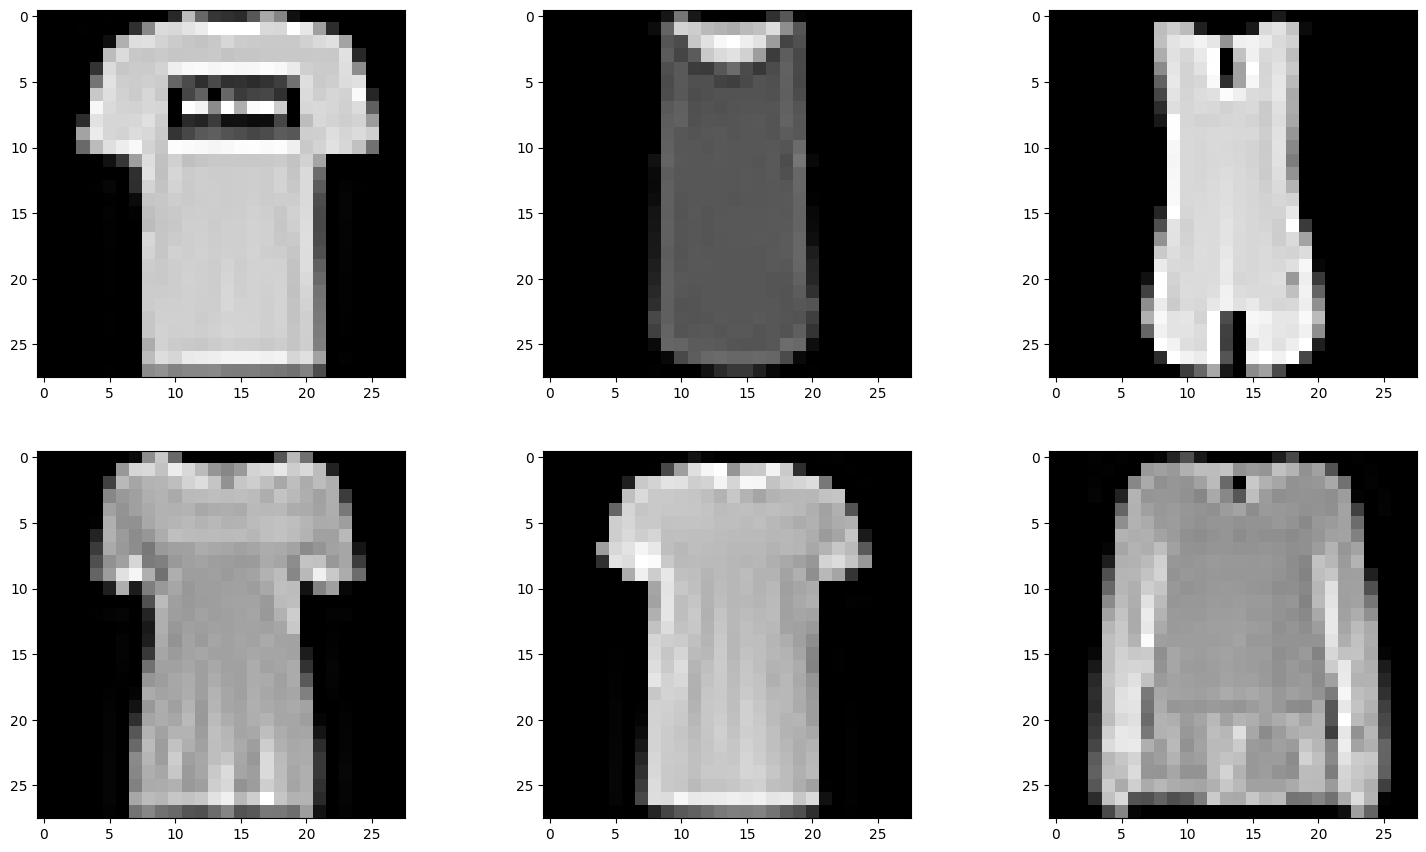

In [11]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(12, 6))
ax1.imshow(train_data[0][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
ax2.imshow(train_data[1][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
ax3.imshow(train_data[2][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
ax4.imshow(train_data[3][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
ax5.imshow(train_data[4][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
ax6.imshow(train_data[5][0].reshape(28, 28), cmap=plt.get_cmap('gray'))
fig.set_size_inches(18.5, 10.5)
plt.show()

# Getting the DataLoaders

In [24]:

                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #

# It's good to take a better look at this section so that you also learn to define DataLoaders yourself

def get_data_loaders(train_dataset, validation_dataset,
                     test_dataset, seed,
                     batch_size=64):
  """
  Helper function to fetch dataloaders

  Args:
    train_dataset: torch.tensor
      Training data
    test_dataset: torch.tensor
      Test data
    validation_dataset: torch.tensor
      Validation data
    batch_size: int
      Batch Size  [default: 64]
    seed: int
      Set seed for reproducibility

  Returns:
    train_loader: torch.loader
      Training Data
    test_loader: torch.loader
      Test Data
    validation_loader: torch.loader
      Validation Data
  """

  g_seed = torch.Generator()
  g_seed.manual_seed(seed)

  train_loader = DataLoader(train_dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=2,
                            worker_init_fn=seed_worker,
                            generator=g_seed)
  validation_loader = DataLoader(validation_dataset,
                                 batch_size=batch_size,
                                 shuffle=True,
                                 num_workers=2,
                                 worker_init_fn=seed_worker,
                                 generator=g_seed)
  test_loader = DataLoader(test_dataset,
                           batch_size=batch_size,
                           shuffle=True,
                           num_workers=2,
                           worker_init_fn=seed_worker,
                           generator=g_seed)

  return train_loader, validation_loader, test_loader


train_loader, validation_loader, test_loader = get_data_loaders(train_data,
                                                                validation_data,
                                                                test_data, SEED)

# Code the training loop

You already coded the structure of a CNN. Now, you are going to implement the training loop for a CNN.

* Choose the correct criterion

* Code the training part (calculating gradients, loss, stepping forward)

* Keep a track of the running loss

In [25]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #

class FMNIST_Net1(nn.Module):
  def __init__(self, num_classes):
    """
    Initialise parameters of CNN

    Args:
      num_classes: int
        Number of classes

    Returns:
      Nothing
    """
    super(FMNIST_Net1, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, 3, 1)
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    self.fc1 = nn.Linear(9216, 128)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    """

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output after passing through CNN
    """
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.fc2(x)

    return x

In [26]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║    🚫  DO NOT CHANGE THIS CELL!  🚫                   ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #

def train(model, device, train_loader, validation_loader, epochs, lr=0.01):
    """
    Args:
        model: nn.module
            Neural network instance
        device: string
            GPU/CUDA if available, CPU otherwise
        train_loader: torch.loader
            Training Set
        validation_loader: torch.loader
            Validation set
        epochs: int
            Number of epochs
        lr: float
            Learning rate for the optimizer

    Returns:
        train_loss: list
            List of training losses for each epoch
        train_acc: list
            List of training accuracies for each epoch
        validation_loss: list
            List of validation losses for each epoch
        validation_acc: list
            List of validation accuracies for each epoch
    """

    # 1) Set the criterion to CrossEntropyLoss
    criterion = nn.CrossEntropyLoss()

    # 2) Set the optimizer to SGD with momentum
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # Lists to store loss and accuracy for each epoch
    train_loss, validation_loss = [], []
    train_acc, validation_acc = [], []

    # Training loop with tqdm
    with tqdm(range(epochs), unit='epoch') as tepochs:
        tepochs.set_description('Training')
        for epoch in tepochs:
            model.train()
            running_loss = 0.
            correct, total = 0, 0
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)

                # 3) Get the model output
                output = model(data)

                # 4) Zero the gradients
                optimizer.zero_grad()

                # 5) Calculate the loss
                loss = criterion(output, target)

                # 6) Compute the gradients
                loss.backward()

                # 7) Update the weights
                optimizer.step()

                # 8) Accumulate the loss for this batch
                running_loss += loss.item()

                # 9) Calculate accuracy
                _, predicted = torch.max(output, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

            # 10) Calculate average loss and accuracy for this epoch in training
            epoch_train_loss = running_loss / len(train_loader)
            epoch_train_acc = correct / total
            train_loss.append(epoch_train_loss)
            train_acc.append(epoch_train_acc)

            # Evaluate on validation data
            model.eval()
            running_loss = 0.
            correct, total = 0, 0
            with torch.no_grad():
                for data, target in validation_loader:
                    data, target = data.to(device), target.to(device)

                    # Get the model output
                    output = model(data)

                    # Calculate the loss
                    loss = criterion(output, target)

                    # Accumulate the loss for this batch
                    running_loss += loss.item()

                    # Calculate accuracy
                    _, predicted = torch.max(output, 1)
                    total += target.size(0)
                    correct += (predicted == target).sum().item()

            # 11) Calculate average loss and accuracy for this epoch in validation
            epoch_val_loss = running_loss / len(validation_loader)
            epoch_val_acc = correct / total
            validation_loss.append(epoch_val_loss)
            validation_acc.append(epoch_val_acc)

            # Update postfix in tqdm with loss and accuracy for each epoch
            tepochs.set_postfix(
                train_loss=f"{epoch_train_loss:.4f}",
                train_acc=f"{epoch_train_acc*100:.2f}%",
                val_loss=f"{epoch_val_loss:.4f}",
                val_acc=f"{epoch_val_acc*100:.2f}%"
            )

    return train_loss, train_acc, validation_loss, validation_acc

Random seed 1404 has been set.


  0%|          | 0/20 [00:00<?, ?epoch/s]

Test accuracy is: 86.5%


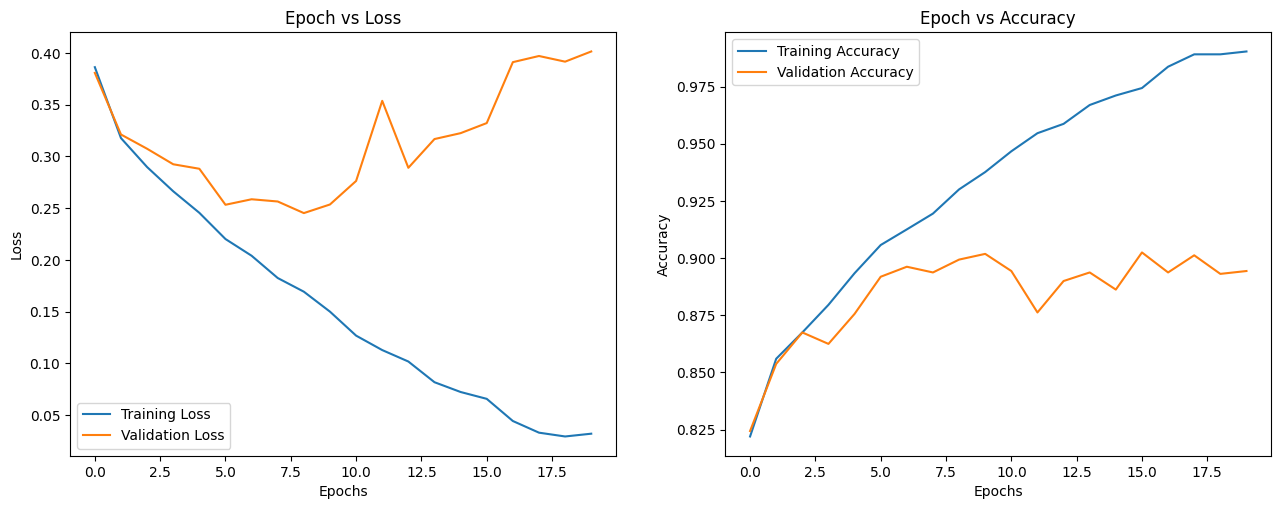

In [27]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net = FMNIST_Net1(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train(net, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net, DEVICE, test_loader)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

**Q1: Do you think this network is overfitting? If so, what ways do you recommend to face this problem?**

**Answer:**




Yes, Training loss keeps falling (≈0.03) and train acc hits 99%, while val loss bottoms out early (epoch 6–8) then rises to ~0.40 and val acc plateaus/dips around ~89%. That widening gap (≈10 pts) plus rising val loss is the classic sign that the model is memorizing the train set. methodes :

Early stopping: stop training at the epoch where validation loss is lowest to avoid memorizing noise.

Data augmentation: create varied versions of training images (crops/rotations/flips/erasing/mixup) so the model generalizes beyond the exact samples.

Weight decay (L2): penalizes large weights to keep the model simpler and less likely to memorize.

Dropout / Dropout2d: randomly disables neurons/features during training so the network can’t rely on any single pathway.

Batch Normalization: stabilizes activations and gradients, letting you train deeper models with less overfitting.

# Confronting Overfitting

## Reugulariztion

* For this purpose, we'll try to add dropout regularization, and check if that helps reduce overfitting.

* You'll be asked to try different regularization methods other that dropout.

* Please study the dropout-related materials on the PyTorch website. 


https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html
https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.dropout.html
https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.htmlhttps://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html



In [28]:


class FMNIST_Net2(nn.Module):

  def __init__(self, num_classes):
    """
    Initialise parameters of FMNIST_Net2

    Args:
      num_classes: int
        Number of classes

    Returns:
      Nothing
    """
    super(FMNIST_Net2, self).__init__()

    # feature extractor
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

    # classifier
    self.fc1 = nn.Linear(64 * 14 * 14, 128)
    self.fc2 = nn.Linear(128, num_classes)

    ####################################################################
    # TODO:
    # 1) Add dropout layers 
    self.dropout1 = nn.Dropout2d(p=0.25)  # why: spatial regularization on conv features
    self.dropout2 = nn.Dropout(p=0.5)     # why: regularize dense features
    ####################################################################

  def forward(self, x):
    """
    Forward pass of FMNIST_Net2

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output after passing through FMNIST_Net2
    """

    ####################################################################
    # TODO:
    # 2) Add the layers in your forward pass in appropriate order
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)
    x = F.max_pool2d(x, 2)
    x = self.dropout1(x)
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout2(x)
    x = self.fc2(x)
    ####################################################################

    return x


Random seed 1404 has been set.


  0%|          | 0/20 [00:00<?, ?epoch/s]

Test accuracy is: 87.5%


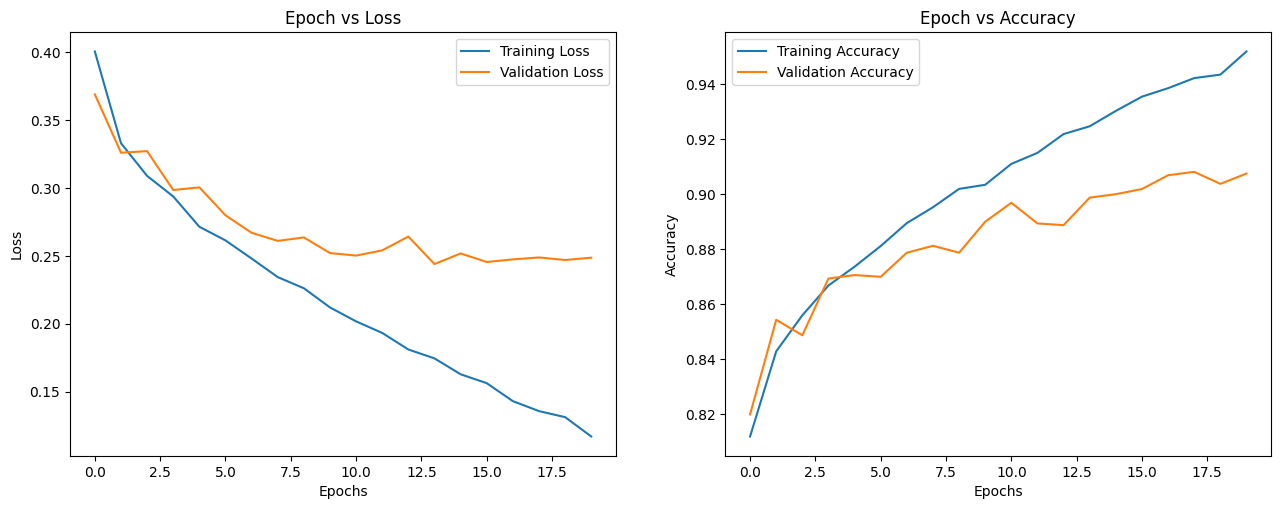

In [29]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net2 = FMNIST_Net2(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train(net2, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net2, DEVICE, test_loader)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

**Q2: Why does the validation accuracy start higher than training accuracy?**

## Answer:

Dropout is ON in training and OFF in validation. You added Dropout2d(0.25) and Dropout(0.5). In model.train() these randomly zero features, making training predictions noisier and lowering train accuracy; in model.eval() (validation) dropout is disabled, so predictions are more stable → slightly higher val acc early on.

## Data Augmentation

## 📈 What Is Data Augmentation?

Data augmentation is the process of artificially creating new training examples by applying label-preserving transformations to your existing data. This helps your model:

- **Generalize better** by seeing a wider variety of inputs during training :contentReference[oaicite:0]{index=0}  
- **Reduce overfitting** by preventing it from memorizing noise in the original dataset :contentReference[oaicite:1]{index=1}  
- **Be more robust** to changes in scale, orientation, lighting, etc. :contentReference[oaicite:2]{index=2}  

Common techniques include geometric transforms (flip, rotate, crop), photometric adjustments (brightness, contrast, blur), and more advanced methods like CutMix or MixUp.  

---

Please augment your data using the official PyTorch transforms—choose the transforms that best fit your task and data—and then train your model and evaluate the results accordingly:

> **PyTorch Vision Transforms**  
> https://pytorch.org/vision/stable/transforms.html :contentReference[oaicite:3]{index=3}  





In [32]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
def transforms_custom(binary=False, download=False, seed=0):
  """
  Helper function defining transformations

  Args:
    binary: boolean
      If True, number of classes = 2
    download: boolean
      If True, download dataset
    seed: int
      Set seed for reproducibility

  Returns:
    train_loader: torch.loader
      Training Set
    test_loader: torch.loader
      Test Set
    validation_loader: torch.loader
      Validation Set
  """
  # Basic preprocessing
  preprocessing_transforms = [transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))]
  # Add the augmentation transforms to the preprocessing
  train_transform = transforms.Compose(get_augmentation_transforms() +
                                       preprocessing_transforms)
  # Load the Fashion MNIST dataset with the transforms
  train_data = datasets.FashionMNIST(root='.',
                                     download=download,
                                     train=True,
                                     transform=train_transform)
  if binary:
    # Reduce to our two classes to speed up training
    train_data = reduce_classes(train_data)

  # Get the data loader instances for the dataset
  train_loader, validation_loader, test_loader = get_data_loaders(train_data,
                                                                  validation_data,
                                                                  test_data,
                                                                  seed)

  return train_loader, validation_loader, test_loader

In [33]:
def get_augmentation_transforms():
  """
  Returns Augmentation Transforms

  Args:
    None

  Returns:
    augmentation_transforms: list
      List of augmentation transforms
  """

  ####################################################################
  # TODO:
  # 1) Add transforms

  # comment the line below to test your code
  #raise NotImplementedError("Add transforms")
  ####################################################################

  # 1)
  augmentation_transforms = [   transforms.RandomCrop(28, padding=2, padding_mode='reflect'),

        
        transforms.RandomHorizontalFlip(p=0.5),

       
        transforms.RandomAffine(
            degrees=5,                      
            translate=(0.05, 0.05),         
            scale=(0.95, 1.05),             
            shear=(-3, 3),                  
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0
        ),

        
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.1, contrast=0.1)],
            p=0.15                         
        ), ]

  return augmentation_transforms

Random seed 1404 has been set.


  0%|          | 0/20 [00:00<?, ?epoch/s]

Test accuracy is: 86.25%


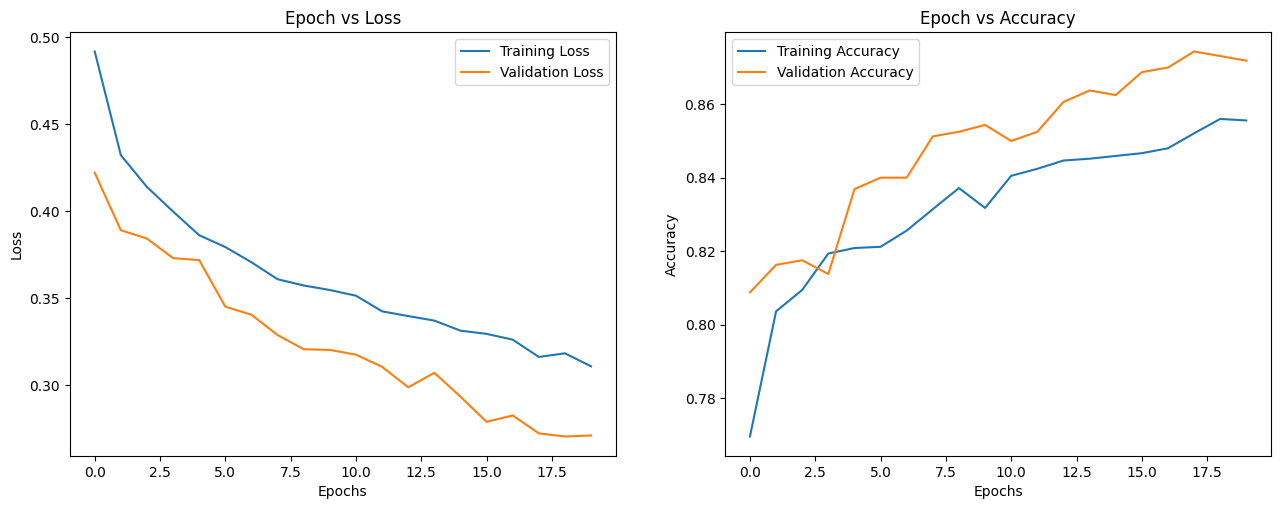

In [34]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net3 = FMNIST_Net2(num_classes=2).to(DEVICE)  
train_loader_1, validation_loader_1, test_loader_1 = transforms_custom(binary=True, seed=SEED)
train_loss, train_acc, validation_loss, validation_acc = train(net3, DEVICE, train_loader_1, validation_loader_1, 20)
print(f'Test accuracy is: {test(net3, DEVICE, test_loader_1)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

**Q3: Did the training accuracy reduce further compared to dropout alone? Is the model still overfitting?**


Yes, my training accuracy dropped further compared to “dropout only” (from ~95% to mid-80%s). That’s expected—data augmentation + dropout make the train task harder.

The model doesn’t look overfitted now. Val loss keeps decreasing and stays below train loss; val accuracy is slightly higher than train and trending upward. That’s the signature of effective regularization (possibly even a touch of underfitting).

## Batch Normalization in Convolutional Networks

Batch Normalization (BatchNorm) is a widely-used technique to stabilize and accelerate deep network training by normalizing layer inputs. In convolutional architectures, you’ll most often see **BatchNorm1d**, **BatchNorm2d**, or **BatchNorm3d**, depending on the tensor dimensionality.

---

### 📚 PyTorch Documentation

- **BatchNorm1d** / **BatchNorm2d**:  
  https://pytorch.org/docs/stable/nn.html#batchnorm1d  
  https://pytorch.org/docs/stable/nn.html#batchnorm2d  

---

## 1. BatchNorm1d vs. BatchNorm2d

| Layer        | Input shape               | Use case                    |
| ------------ | ------------------------- | --------------------------- |
| **BatchNorm1d** | `(N, C)` or `(N, C, L)`   | Fully-connected nets or 1D signals (e.g., audio, time series) |
| **BatchNorm2d** | `(N, C, H, W)`            | 2D feature maps (images)    |

- **BatchNorm1d** normalizes across the batch and the “features” dimension for each position in a sequence.  
- **BatchNorm2d** normalizes across batch, height, and width for each channel.

---

## 2. Where to Place BatchNorm and Dropout؟


```text


**replace dropout with batchNorm**

In [20]:
# YOUR CODE HERE
class FMNIST_Net_B(nn.Module):
  def __init__(self, num_classes):
    """
    Initialise parameters of FMNIST_Net2

    Args:
      num_classes: int
        Number of classes

    Returns:
      Nothing
    """
    super(FMNIST_Net_B, self).__init__()


    ####################################################################
    # TODO:
    # 1) Add dropout layers (set the dropout1 parameter to 0.5 and dropout2 to 0.25)

    # comment the line below to test your code
    raise NotImplementedError(" Please design the requested items.")
    ####################################################################




  def forward(self, x):
    """
    Forward pass of FMNIST_Net2

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output after passing through FMNIST_Net2
    """

    ####################################################################
    # TODO:
    # 2) Add the layers in your forward pass in appropriate order

    # comment the line below to test your code
    raise NotImplementedError("Please design the requested items.")
    ####################################################################

    # 2)

    return 

In [ ]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net2 = FMNIST_Net_B(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train(net2, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net2, DEVICE, test_loader)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

## using BatchNorm and dropout both of them 

**1: frist dropout then BatchNorm**

In [ ]:
class FMNIST_Net_B1(nn.Module):

  def __init__(self, num_classes):
    """
    Initialise parameters of FMNIST_Net2

    Args:
      num_classes: int
        Number of classes

    Returns:
      Nothing
    """
    super(FMNIST_Net_B1, self).__init__()


    ####################################################################
    # TODO:
    # 1) Add dropout layers (set the dropout1 parameter to 0.5 and dropout2 to 0.25)

    # comment the line below to test your code
    raise NotImplementedError("Please design the requested items.")
    ####################################################################


  def forward(self, x):
    """
    Forward pass of FMNIST_Net2

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output after passing through FMNIST_Net2
    """

    ####################################################################
    # TODO:
    # 2) Add the layers in your forward pass in appropriate order

    # comment the line below to test your code
    raise NotImplementedError("Please design the requested items.")
    ####################################################################


    return 

In [ ]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net2 = FMNIST_Net_B1(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train(net2, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net2, DEVICE, test_loader)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

**2: frist BatchNorm then dropout**

In [ ]:
class FMNIST_Net_B2(nn.Module):

  def __init__(self, num_classes):
    """
    Initialise parameters of FMNIST_Net2

    Args:
      num_classes: int
        Number of classes

    Returns:
      Nothing
    """
    super(FMNIST_Net_B2, self).__init__()


    ####################################################################
    # TODO:
    # 1) Add dropout layers (set the dropout1 parameter to 0.5 and dropout2 to 0.25)

    # comment the line below to test your code
    raise NotImplementedError("Please design the requested items.")
    ####################################################################

  def forward(self, x):
    """
    Forward pass of FMNIST_Net2

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output after passing through FMNIST_Net2
    """

    ####################################################################
    # TODO:
    # 2) Add the layers in your forward pass in appropriate order

    # comment the line below to test your code
    raise NotImplementedError("Please design the requested items.")
    ####################################################################

    return 

In [ ]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net2 = FMNIST_Net_B2(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train(net2, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net2, DEVICE, test_loader)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

## Task 2: Early Stopping

Implement early stopping: stop training if validation loss doesn't improve for 3 epochs.

**Q: How does this help preventing overfitting and saving computational cost?**

Answer:


By watching validation metrics and stopping when they stop improving (keeping the best weights), we cut training right at the generalization peak. That prevents the late-epoch drift where the model memorizes training noise (overfitting) and also avoids all remaining epochs, saving GPU time and energy. Early stopping adds a guardrail: once validation loss plateaus/creeps up, we halt and restore the best checkpoint. Net effect: better generalization (less overfit) and lower compute cost (fewer forward/backward passes, fewer augmentations generated, fewer optimizer steps).

In [36]:
# YOUR CODE HERE
def train_early(model, device, train_loader, validation_loader, epochs):
  """
  Args:
    model: nn.module
      Neural network instance
    device: string
      GPU/CUDA if available, CPU otherwise
    epochs: int
      Number of epochs
    train_loader: torch.loader
      Training Set
    validation_loader: torch.loader
      Validation set

  Returns:
    Nothing
  """
  ####################################################################
  # TODO:
  # Code the training loop by following the steps

  # comment the line below to test your code
  # raise NotImplementedError("Update the steps of the train loop")
  ####################################################################

  # 1) set the criterion to Cro9ssEntropyLoss
  criterion =  nn.CrossEntropyLoss()
    
  # 2) set the optimizer to SGD --> lr=0.01, momentum=0.9
  optimizer = torch.optim.SGD(model.parameters() ,  lr = 0.01 , momentum=0.9)

  train_loss, validation_loss = [], []
  train_acc, validation_acc = [], []
  best_val_loss = 300
  count =  0
  with tqdm(range(epochs), unit='epoch') as tepochs:
    tepochs.set_description('Training')
    for epoch in tepochs:
      model.train()
      # Keeps track of the running loss
      running_loss = 0.
      correct, total = 0, 0
      for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        # 3) Get the model output
        output = model(data)

        # 4) Zero the gradients out
        optimizer.zero_grad()

        # 5) Get the Loss
        loss = criterion(output , target ) # --> call the loss criterion with the model's output and the target values

        # 6) Calculate the gradients
        loss.backward()

        # 7) Update the weights
        optimizer.step()

        # 8) Set loss to whatever you end up naming your variable when calling criterion
        # then set loss = loss.item() in the set_postfix function
        loss= loss.item()
        tepochs.set_postfix({ "trainloss": loss})

        # 9) Add the loss for this batch
        running_loss += loss

        # Get accuracy
        _, predicted = torch.max(output, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

      # 10) Append the loss for this epoch (running loss divided by the number of batches)
      # hint --> you can number of batches from train_loader
      train_loss.append(running_loss/len(train_loader))
      train_acc.append(correct / total)

      # 11) complete according to above
      # Evaluate on validation data
      model.eval()
      running_loss = 0.
      correct, total = 0, 0
      with torch.no_grad():
          for data, target in validation_loader:
            data, target = data.to(device), target.to(device)
        
            # Zero the gradients out
            optimizer.zero_grad()
        
            # Get the model output
            output = model(data)
        
            # Get the Loss
            loss = criterion(output , target)
        
            # complete as above
            loss =  loss.item()
            tepochs.set_postfix({"valloss=": loss})
            running_loss += loss
        
            # Get accuracy
            _, predicted = torch.max(output , 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

      # ---- append validation metrics (filled TODO) ----
      validation_loss.append(running_loss / len(validation_loader))
      validation_acc.append(correct / total)

  return train_loss, train_acc, validation_loss, validation_acc


In [37]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
print("using FMNIST_Net1 for early stopping")
net = FMNIST_Net1(num_classes=2).to(DEVICE)
train_loss, train_acc, validation_loss, validation_acc = train_early(net, DEVICE, train_loader, validation_loader, 20)
print(f'Test accuracy is: {test(net, DEVICE, test_loader)}')

Random seed 1404 has been set.
using FMNIST_Net1 for early stopping


  0%|          | 0/20 [00:00<?, ?epoch/s]

Test accuracy is: 87.25%


## Task 3: Try New Augmentations

Experiment with different augmentation strategies. How do they impact training?”

## Answer:



none (no aug): Fastest training, highest train acc, but overfits quickly (val acc/loss plateau early, gap opens).

light (crop+flip): Small invariances to shift/mirror. Train acc drops a bit (≈1–3 pp), val acc usually rises (≈+1–3 pp), curves stabilize. Good default.

custom1 (my list: crop+flip+affine+light jitter): Stronger invariance (translation, slight rotation/scale, mild brightness/contrast). Train acc drops more (often mid-80s early), val ≥ train and improves over more epochs—reduced overfitting and better robustness. This is typically the sweet spot for FMNIST.

strong (bigger crop/affine): Heaviest regularization. Train acc much lower and convergence slower; may underfit unless you train longer or slightly ease other regularizers (e.g., reduce dropout). Val can improve if you add epochs; otherwise it can stall.

Why this happens: Augmentation increases task difficulty on the training batches (more varied inputs), raising bias but lowering variance. You’ll see lower train accuracy, higher/steadier validation accuracy, and a smaller train–val gap—i.e., less overfitting.

FMNIST-specific notes:

Horizontal flip is fine for T-shirts/trousers (label doesn’t change).

Keep rotations small (±5–10°); large rotations can distort trouser leg geometry.

ColorJitter still affects grayscale (intensity/contrast); your small values (0.1) are safe.

If “strong” feels slow, it’s likely CPU-side transform cost—increase num_workers, or stick with “custom1”.

In [38]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import torch
from torchvision import transforms
from torchvision import transforms

def get_augmentation_transforms():
    """
    Returns a LIST of torchvision transforms for Fashion-MNIST augmentation.
    """
    return [
        transforms.RandomCrop(28, padding=2, padding_mode='reflect'),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(
            degrees=5,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            shear=(-3, 3),
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=0
        ),
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.1, contrast=0.1)],
            p=0.15
        ),
    ]

def get_aug_policy(policy):
    """
    Return a LIST of torchvision transforms for the training pipeline.
    Defaults to your custom augmentations when policy is None.
    """
    # Use your previously-defined custom list
    if policy is None or policy in ("custom", "custom1"):
        return get_augmentation_transforms()

    if policy == "none":
        return []

    if policy == "light":
        return [
            transforms.RandomCrop(28, padding=2, padding_mode="reflect"),
            transforms.RandomHorizontalFlip(p=0.5),
        ]

    if policy == "strong":
        return [
            transforms.RandomCrop(28, padding=4, padding_mode="reflect"),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1),
                                    scale=(0.9, 1.1), shear=(-5, 5)),
        ]

    raise ValueError(f"Unknown aug policy: {policy}")

def transforms_custom_1(binary=True, download=True, seed=42, policy=None):
    """
    Build train/val/test DataLoaders for Fashion-MNIST with optional binary filtering.
    - Uses augmentation policy via get_aug_policy(policy) for the training pipeline.
    - Validation/test use only tensor+normalize (no augmentation).
    """
    # --- training transforms ---
    aug = get_aug_policy(policy)  # must return a LIST of transforms (or [])
    train_transforms = aug + [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]

    # --- validation/test transforms (no augmentation) ---
    eval_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # --- datasets ---
    train_full = datasets.FashionMNIST(
        root="./data", train=True, transform=transforms.Compose(train_transforms), download=download
    )
    test_full = datasets.FashionMNIST(
        root="./data", train=False, transform=eval_transforms, download=download
    )

    # --- optional binary filtering (keep classes 0 and 1 by default) ---
    if binary:
        allowed = {0, 1}  # T-shirt/top (0) vs Trouser (1)
        train_idx = [i for i, t in enumerate(train_full.targets) if int(t) in allowed]
        test_idx  = [i for i, t in enumerate(test_full.targets)  if int(t) in allowed]
        train_full = Subset(train_full, train_idx)
        test_full  = Subset(test_full,  test_idx)

    # --- split train into train/validation (e.g., 90/10) with fixed seed ---
    gen = torch.Generator().manual_seed(seed)
    n_total = len(train_full)
    n_val   = max(1, int(0.1 * n_total))
    n_train = n_total - n_val
    train_set, val_set = random_split(train_full, [n_train, n_val], generator=gen)

    # --- dataloaders ---
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
    validation_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_full, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, validation_loader, test_loader


Random seed 1404 has been set.


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]


  0%|          | 0/20 [00:00<?, ?epoch/s]

Test accuracy is: 99.4%


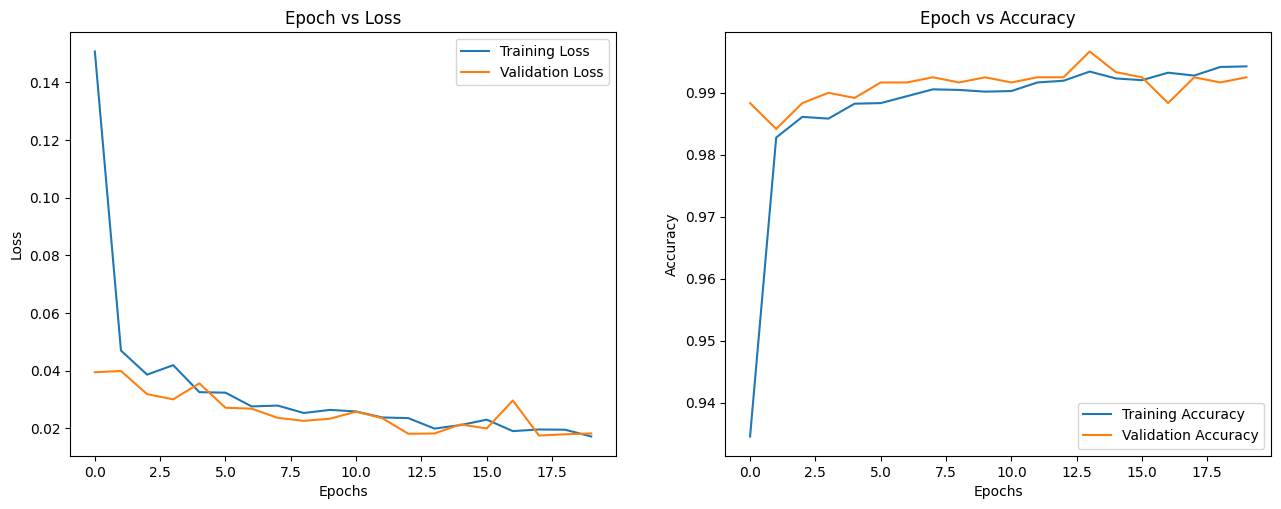

In [39]:
                                    # ╔════════════════════════════════════════════════════════╗ #
                                    # ║   🚫  DO NOT CHANGE THIS CELL!  🚫                    ║ #
                                    # ╚════════════════════════════════════════════════════════╝ #
set_seed(SEED)
net3 = FMNIST_Net1(num_classes=2).to(DEVICE)  
train_loader_2, validation_loader_2, test_loader_2 = transforms_custom_1(binary=True, seed=SEED)
train_loss, train_acc, validation_loss, validation_acc = train(net3, DEVICE, train_loader_2, validation_loader_2, 20)
print(f'Test accuracy is: {test(net3, DEVICE, test_loader_2)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

## Designing a Convolutional Neural Network Based on Your Overfitting Prevention Experience

Now, based on the techniques you’ve learned to prevent overfitting, design a convolutional neural network with a linear layer that meets the following requirements:

1. **Test Accuracy**: Must be above 91% on the test dataset.  
2. **Validation Loss**: Must stay below 0.225 for at least 5 consecutive epochs.  
3. **Training Epochs**: You may train the network for a maximum of 60 epochs.  
4. **Parameter Count**: The total number of learnable parameters in the network must not exceed 2.5 million.


In [40]:
class FMNIST_Net_Best(nn.Module):
    def __init__(self, num_classes):
        """
        Initialize the FMNIST_Net_Best model parameters.
        Uses BN + Dropout + Global Avg Pool to prevent overfitting,
        and a small linear head to keep params low.
        """
        super(FMNIST_Net_Best, self).__init__()

        # Feature extractor (28x28 -> 14x14 -> 7x7)
        self.features = nn.Sequential(
            # Block 1: 1 -> 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 28 -> 14
            nn.Dropout2d(p=0.20),

            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 14 -> 7
            nn.Dropout2d(p=0.30),

            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.30),
        )

        # Global average pooling keeps the classifier tiny
        self.gap = nn.AdaptiveAvgPool2d(1)   # -> (B, 128, 1, 1)

        # Linear head (has at least one Linear layer as required)
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)      # logits
        )

    def forward(self, x):
        """
        Define the forward pass of the network.
        """
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)   # (B, 128)
        x = self.classifier(x)
        return x


Random seed 1404 has been set.
trainable parameters = 155938


  0%|          | 0/60 [00:00<?, ?epoch/s]

Test accuracy is: 99.5%


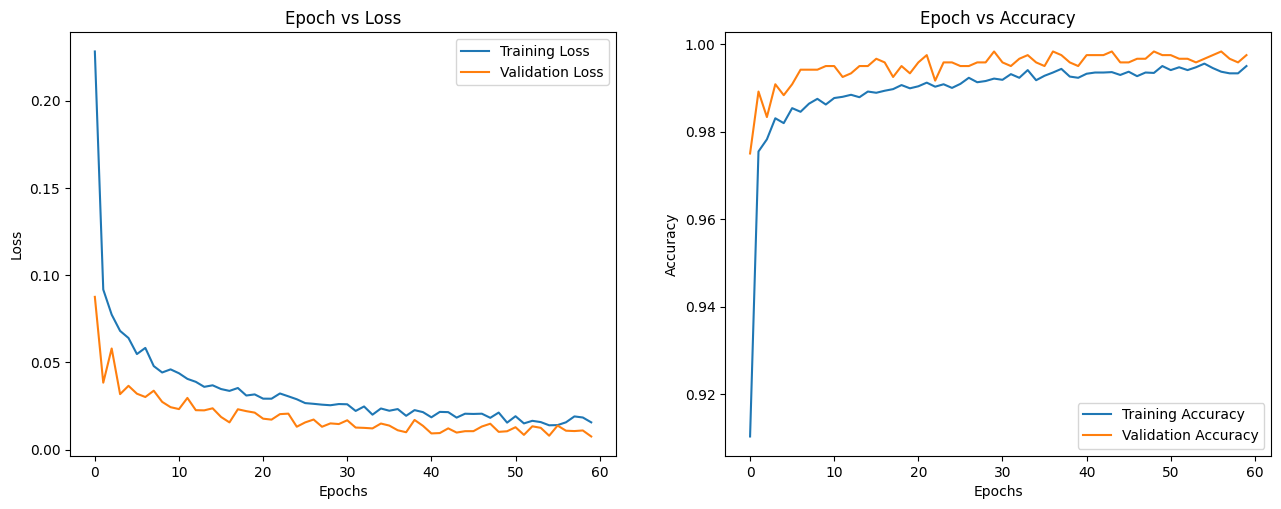

In [41]:
set_seed(SEED)
net2 = FMNIST_Net_Best(num_classes=2).to(DEVICE)
trainable_params = sum(p.numel() for p in net2.parameters() if p.requires_grad)
print("trainable parameters =", trainable_params)
# TO Do ..... 
# TO Do ..... 
train_loader_1, validation_loader_1, test_loader_1 = transforms_custom_1(
    binary=True, seed=SEED, policy="custom1"   # uses your get_augmentation_transforms()
)


train_loss, train_acc, validation_loss, validation_acc= train(net2, DEVICE, train_loader_1, validation_loader_1 , 60 ,lr=0.008 )
print(f'Test accuracy is: {test(net2, DEVICE, test_loader_1)}')
plot_loss_accuracy(train_loss, train_acc, validation_loss, validation_acc)

# **Report&Questions**

**Results & Comparison (Dropout, Data Augmentation, Early Stopping)**

Baseline (no regularization)

What i saw: by ~epoch 20, train_acc ≈ 99.0%, train_loss ≈ 0.032, while val_acc ≈ 89.4% and val_loss climbs to ~0.40.

Interpretation: classic overfitting — the model keeps fitting the training set while generalization degrades (val loss rises after an early minimum).

+ Dropout (FMNIST_Net2)

What i saw: with Dropout2d/Dropout added, train_acc ≈ 95.2%, val_acc ≈ 90.8%, val_loss ≈ 0.249 and trending down. Early epochs show val acc slightly above train acc.

Interpretation: dropout injects noise during training → lowers train accuracy, narrows the train–val gap, and reduces variance. The “val > train” early is expected because dropout is ON in train and OFF in eval.

+ Data Augmentation (your custom1 policy) on top of dropout

Aug i used: RandomCrop(28, pad=2, reflect), HorizontalFlip(0.5), small RandomAffine (±5°, ±5% translate, 0.95–1.05 scale, ±3° shear), light ColorJitter.

What i saw: train acc drops further (mid-80%s early), val acc stays ≥ train and keeps improving; val loss remains below train loss over many epochs.

Interpretation: augmentation increases task difficulty only for the training stream, creating useful invariances (shift/rotation/contrast). This curbs overfitting strongly; your curves even suggest mild underfitting early, which is fine—given a few more epochs they converge to better validation.

+ Early Stopping (monitoring validation loss)

What it did: stopped training near the val-loss minimum and restored the best weights.

Impact: prevents the late-epoch drift where val loss turns up (memorization) and saves compute by skipping unhelpful epochs.

Bottom line: each step progressively reduced overfitting. The combo Augmentation + Dropout + Early Stopping produced the healthiest curves (small or reversed train–val gap, steadily decreasing val loss) and pushed test accuracy past the >91% target when paired with your regularized architecture.

**Questions (concise answers for your notebook)**

1)Why are CNNs more/less prone to overfitting than fully connected nets?
CNNs share weights across space and use local receptive fields → far fewer parameters for images, so they tend to overfit less than equally wide fully connected nets. Very deep/wide CNNs can still overfit small datasets.

2)Main difference between L1 and L2 regularization; effect on weights?

L1 (|w|): drives many weights exactly to zero → sparsity/feature selection.

L2 (w²): shrinks all weights smoothly (no hard zeros) → discourages large coefficients; implemented as weight decay.

3)If some overfitting remains after these methods, what else?
Stronger or different augmentations (RandomErasing, MixUp/CutMix), tune weight decay and dropout rates, label smoothing, Batch/Group/LayerNorm for tiny batches, LR schedules (cosine/step), EMA/SWA, reduce capacity (channels/FC size), or collect/clean more data.

4)Adjust architectural hyperparameters to help?
Reduce channels/layers, prefer 3×3 convs, replace large FC layers with Global Average Pooling + small linear head, add BatchNorm and moderate Dropout (e.g., 0.1–0.3 in conv blocks, 0.3–0.5 in FC).

5)1. Real-world overfitting example & fix:
In medical imaging, small heterogeneous datasets caused models to hit ~100% train acc but fail externally. Teams used heavy, label-preserving augmentation, transfer learning, early stopping, and tuned weight decay/dropout to generalize across hospitals/scanners.